In [ ]:
# 準備
# データの確認とバイアス除去

import pandas as pd

df = pd.read_csv('./data/boston.csv')

df.head() # 最初の5行を表示

# 黒人のカラムを除去
df = df.drop(columns=['黒人'])

# csvファイルに保存
df.to_csv('./data/boston_dropped_bias.csv', index=False)


### 線形回帰

線形回帰（Linear Regression）は、変数間の線形な関係性をモデル化する統計的手法。

さまざまな分野（企業の売上予測、気温変化による作物の生産量の変動予測、ある薬の効果の量的評価など）で応用され、相関関係や因果関係を調べたい場合に使用される。

>線形回帰は、理解しやすく、実装が容易であるためよく使われる。
しかし、現実の多くの関係は非線形であり、線形回帰モデルではうまく捉えきれないこともある。
また、線形回帰は説明変数と従属変数間の独立性や、誤差項が正規分布に従うといった仮定に基づいている。これらの仮定が実際のデータに当てはまらない場合、モデルの予測精度が低下する。

**基本的な考え方**

線形回帰モデルの基本的な式
$$ y=ax+b $$
- y は 目的変数（予測したい変数）
- x は 説明変数（予測に使う変数）
- a は 傾き（xの変化に対するyの変化の比率）
- b は y 切片（直線がy軸と交わる点）

回帰分析の目的は、観測データに基づいてaとbの最適な推定値を見つけ出し、それによって新しい
x値に対するyの予測値を計算することです。


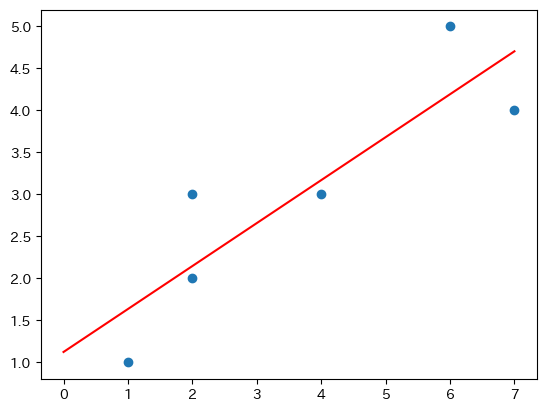

In [8]:
# NumPyを使用した直線の近似
import numpy as np
import matplotlib.pyplot as plt

# 1次元の線形回帰を行う関数
def reg1dim(x, y):
    x = np.array(x) # xをNumPy配列に変換
    y = np.array(y) # yをNumPy配列に変換
    n = len(x) # データの数

    # 傾きaと切片bを計算
    a = ((np.dot(x, y) - y.sum() * x.sum() / n) /
         ((x ** 2).sum() - x.sum()**2 / n))
    b = (y.sum() - a * x.sum()) / n

    return a, b



x = [1,2,2,4,6,7]
y = [1,3,2,3,5,4]
plt.scatter(x, y)  # 散布図

a, b = reg1dim(x, y) # 直線の傾きと切片を計算
x = np.linspace(0, 7, 10) # 0から7までの10点を生成
y = a * x + b # 直線の方程式
plt.plot(x, y, color="red")  # 直線
plt.show()

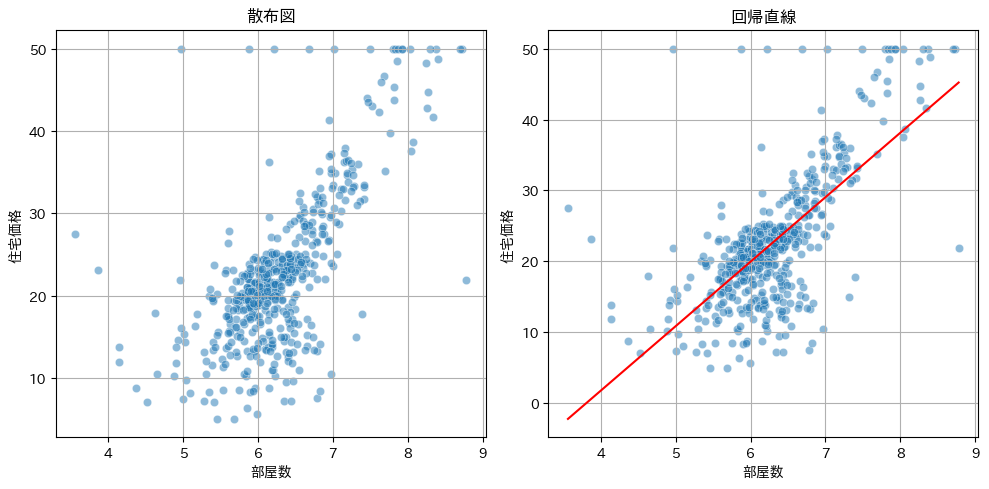

In [28]:
# ボストンデータセットの、住宅価格と部屋数の関係を散布図で描画
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib # matplotlibの日本語化
import numpy as np


# 1次元の線形回帰を行う関数
def reg1dim(x, y):
    x = np.array(x) # xをNumPy配列に変換
    y = np.array(y) # yをNumPy配列に変換
    n = len(x) # データの数

    # 傾きaと切片bを計算
    a = ((np.dot(x, y) - y.sum() * x.sum() / n) /
         ((x ** 2).sum() - x.sum()**2 / n))
    b = (y.sum() - a * x.sum()) / n

    return a, b


df = pd.read_csv('./data/boston_dropped_bias.csv')

# サブプロットの設定
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1行2列のサブプロット

# 散布図のプロット axes[0]と[1]にそれぞれプロット
# axes.flatten() で 2x2 の配列を 1次元のリストのように扱う
for ax in axes.flatten():
    sns.scatterplot(ax=ax, x='部屋数', y='住宅価格', data=df, alpha=0.5)
    ax.grid(True)  # グリッドを表示

axes[0].set_title('散布図')  # タイトルを設定


# 回帰直線のプロット reg1dim関数を使用して、回帰直線の傾きと切片を計算
a, b = reg1dim(df['部屋数'], df['住宅価格'])
x = np.linspace(df['部屋数'].min(), df['部屋数'].max(), 100) # 部屋数の範囲で100点を生成
y = a * x + b # 直線の方程式
axes[1].plot(x, y, color="red")  # 回帰直線をプロット
axes[1].set_title('回帰直線')  # タイトルを設定


plt.tight_layout()
plt.show()







### 説明変数と目的変数

回帰分析やそれに続く機械学習の分野では、関係性を示す式を 「モデル」 と呼び、式の中で、

xを「説明変数」、yを「目的変数」と呼びます。

ここで、$y=ax+b$のような式がモデルの例です。

- **説明変数**: モデルで予測や分析の根拠となる変数。モデルが説明しようとする特性や特徴を持つデータのことを指す。**特徴量** とも呼びます。
- **目的変数**: モデルで予測したい、または分析の対象となる変数。データセットから一つの説明変数を選んで回帰分析を行うことを **「単回帰分析」** という。単回帰分析では、一つの説明変数と目的変数の関係をモデル化する。


### LinearRegression クラス
`LinearRegression`クラスは、Pythonの機械学習ライブラリであるscikit-learnに含まれる線形回帰モデルを実装したクラス。最小二乗法に基づいて、線形回帰モデルを構築する。

In [44]:
# scilit-learnを使用した線形回帰

from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

df = pd.read_csv('./data/boston_dropped_bias.csv')

# データの準備
# 部屋数が二重括弧なのは、scikit-learnのLinearRegressionが2次元の入力を期待しているため。
# 例えば、X = df['部屋数'] とすると、Xは1次元のSeriesになるが、X = df[['部屋数']] とすると、Xは2次元のDataFrameになる。
X = df[['部屋数']].values  # 説明変数（部屋数) numpy配列に変換することで、scikit-learnのモデルに適した形式になる。
y = df['住宅価格']  # 目的変数（住宅価格）

# LinearRegressionクラスは、fitメソッドでモデルを学習させ、predictメソッドで予測を行う。
model = LinearRegression()  # モデルのインスタンスを作成
model.fit(X, y)  # モデルを学習させる 

# 学習したモデルの傾きと切片を表示
print("傾き (a):", model.coef_[0])  # 傾きはcoef_属性に格納されている。今回は1次元なので、最初の要素を表示。
print("切片 (b):", model.intercept_)  # 切片はintercept_属性に格納されている。

# 学習したモデルを使って予測を行う
room=4
predicted_price = model.predict([[room]])  # 部屋数が4のときの住宅価格を予測
print(f"\n部屋数が{room}のときの予測住宅価格:", predicted_price[0])  # 予測値を表示

predicted = model.predict(X)  # Xを使って予測を行う
print("予測値(Xの先頭5件):", predicted[0:5])  # 予測値を表示


# dfに['予測']という新しい列を追加して、予測値を格納
df['予測'] = predicted

# CSVファイルに保存
df.to_csv('./data/boston_with_predictions.csv', index=False)


傾き (a): 9.102108981180308
切片 (b): -34.670620776438554

部屋数が4のときの予測住宅価格: 1.737815148282678
予測値(Xの先頭5件): [25.17574577 23.77402099 30.72803225 29.02593787 30.38215211]


### モデル評価


In [49]:
# 予測データを参照データと比較する

import pandas as pd
df = pd.read_csv('./data/boston_with_predictions.csv')

# 予測値と実際の住宅価格を比較して、誤差率を計算する
df['誤差率'] = (df['予測'] - df['住宅価格']) / df['住宅価格'] * 100

# 部屋数、住宅価格、予測値、誤差率の列を表示
df[['部屋数', '住宅価格', '予測', '誤差率']].head(10)

,部屋数,住宅価格,予測,誤差率
0,6.575,24.0,25.175746,4.898941
1,6.421,21.6,23.774021,10.064912
2,7.185,34.7,30.728032,-11.446593
3,6.998,33.4,29.025938,-13.095994
4,7.147,36.2,30.382152,-16.071403
5,6.430,28.7,23.855940,-16.878258
6,6.012,22.9,20.051258,-12.439920
7,6.172,27.1,21.507596,-20.636178
8,5.631,16.5,16.583355,0.505181
9,6.004,18.9,19.978442,5.706040


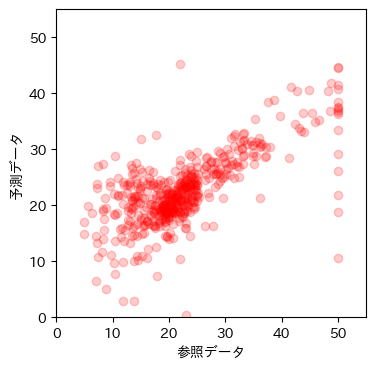

In [50]:
# 予測データとのずれを可視化

import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib # matplotlibの日本語化

df = pd.read_csv('./data/boston_with_predictions.csv')

plt.figure(figsize=(4,4))
plt.scatter(df['住宅価格'], df['予測'], color='red', alpha=0.2)
plt.xlabel('参照データ')
plt.ylabel('予測データ')
plt.xlim(0, 55)
plt.ylim(0, 55)
plt.show()

### 残差ヒストグラム
残差とは、参照データと予測データの差のことを指す。理想的な回帰モデルでは、残差が **正規分布** であること が望ましいとされている。


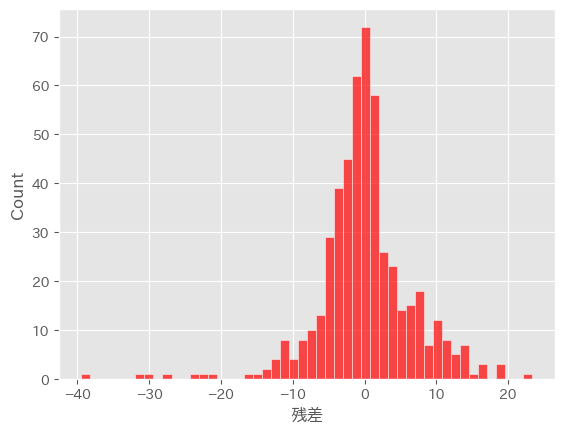

In [59]:
# 残差ヒストグラムを描画

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('./data/boston_with_predictions.csv')
df['残差'] = df['予測'] - df['住宅価格']  # 残差を計算


plt.style.use('ggplot')  # ggplotスタイルを使用
plt.hist(df['残差'], bins=50, color='red', edgecolor='white', alpha=0.7)
plt.xlabel('残差')
plt.ylabel('Count')
plt.show()

### 評価尺度